# Combined Sensitivity Analysis

## 1. Imports and Display Settings

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

## 2. Load the Combined Summary

The merged file stores each category under `categories.goal`, `categories.object`, and `categories.spatial`.

In [3]:
summary_path = Path("combined_sensitivity_summary.json")
if not summary_path.exists():
    summary_path = Path("language_diagnostics/sensitivity_experiment/combined_sensitivity_summary.json")

if not summary_path.exists():
    raise FileNotFoundError(f"Could not find {summary_path}")

summary = pd.read_json(summary_path)
summary = summary.to_dict() if isinstance(summary, pd.DataFrame) else summary

with summary_path.open() as f:
    import json
    summary = json.load(f)

summary_path.resolve()

PosixPath('/zhome/ca/2/206287/vla-robotics/language_diagnostics/sensitivity_experiment/combined_sensitivity_summary.json')

In [4]:
categories = summary["categories"]
variant_rows = []
task_rows = []
timesteps = None

for category_name, category_summary in categories.items():
    overall = category_summary["overall"]
    if timesteps is None:
        timesteps = np.arange(len(overall["mean_l2_per_timestep"]))

    for variant_name, variant_summary in category_summary["variant_types"].items():
        l2 = np.asarray(variant_summary["mean_l2_per_timestep"])
        rel_l2 = np.asarray(variant_summary["mean_rel_l2_per_timestep"])
        variant_rows.append({
            "category": category_name,
            "variant": variant_name,
            "mean_l2": float(l2.mean()),
            "std_l2": float(l2.std()),
            "max_l2": float(l2.max()),
            "mean_rel_l2": float(rel_l2.mean()),
            "std_rel_l2": float(rel_l2.std()),
            "max_rel_l2": float(rel_l2.max()),
            "n_rollouts": int(variant_summary["n_rollouts"]),
        })

    for task_name, task_summary in category_summary["per_task"].items():
        task_variant_means = []
        task_variant_rel_means = []
        for variant_name, variant_summary in task_summary["variant_types"].items():
            l2 = np.asarray(variant_summary["mean_l2_per_timestep"])
            rel_l2 = np.asarray(variant_summary["mean_rel_l2_per_timestep"])
            task_variant_means.append(float(l2.mean()))
            task_variant_rel_means.append(float(rel_l2.mean()))
        task_rows.append({
            "category": category_name,
            "task": task_name,
            "mean_l2": float(np.mean(task_variant_means)),
            "mean_rel_l2": float(np.mean(task_variant_rel_means)),
            "variant_count": len(task_variant_means),
        })

variant_df = pd.DataFrame(variant_rows)
task_df = pd.DataFrame(task_rows)

print(f"Categories: {list(categories)}")
print(f"Variants: {variant_df['variant'].nunique()}")
print(f"Tasks: {task_df['task'].nunique()}")
display(variant_df.head())
display(task_df.head())

Categories: ['goal', 'object', 'spatial']
Variants: 7
Tasks: 15


,category,variant,mean_l2,std_l2,max_l2,mean_rel_l2,std_rel_l2,max_rel_l2,n_rollouts
0,goal,politeness,0.115846,0.091759,0.618707,0.109662,0.094875,0.808678,250
1,goal,verb_paraphrase,0.141012,0.089386,0.663612,0.130406,0.089260,0.855885,250
2,goal,sentence_structure,0.916898,0.490795,2.101493,0.834495,0.441348,1.999989,250
3,goal,verbosity,0.395427,0.197200,1.751403,0.364044,0.181895,1.655401,250
4,goal,carefully,0.122825,0.097228,0.763836,0.116120,0.100883,0.941555,250


,category,task,mean_l2,mean_rel_l2,variant_count
0,goal,put the wine bottle on the rack,0.305941,0.293082,7
1,goal,open the top drawer and put the bowl inside,0.318130,0.282793,7
2,goal,put the cream cheese in the bowl,0.301106,0.291301,7
3,goal,put the wine bottle on top of the cabinet,0.274114,0.256895,7
4,goal,put the bowl on the plate,0.510785,0.466534,7


## 3. Summary Statistics

First, we summarize each category using the overall timestep-averaged distances.

In [6]:
category_overview_rows = []
for category_name, category_summary in categories.items():
    overall = category_summary["overall"]
    mean_l2 = np.asarray(overall["mean_l2_per_timestep"])
    rel_l2 = np.asarray(overall["mean_rel_l2_per_timestep"])
    category_overview_rows.append({
        "category": category_name,
        "n_demos_processed": int(category_summary["n_demos_processed"]),
        "mean_l2": float(mean_l2.mean()),
        "std_l2": float(mean_l2.std()),
        "min_l2": float(mean_l2.min()),
        "max_l2": float(mean_l2.max()),
        "mean_rel_l2": float(rel_l2.mean()),
        "std_rel_l2": float(rel_l2.std()),
        "min_rel_l2": float(rel_l2.min()),
        "max_rel_l2": float(rel_l2.max()),
    })

category_overview = pd.DataFrame(category_overview_rows).set_index("category")
display(category_overview.style.format(precision=4))

,n_demos_processed,mean_l2,std_l2,min_l2,max_l2,mean_rel_l2,std_rel_l2,min_rel_l2,max_rel_l2
category,,,,,,,,,
goal,250,0.3145,0.1509,0.1088,0.9838,0.2900,0.1452,0.0849,1.1706
object,250,0.3240,0.0955,0.1087,0.6375,0.2527,0.0799,0.0827,0.5394
spatial,250,0.3935,0.2261,0.1037,1.7502,0.3531,0.2122,0.0962,1.6882


### Overall category comparison

The bar charts below compare the three categories on absolute and relative L2 distance.

/tmp/pbs.666845.hnode41/ipykernel_1806188/2146265199.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="category", y="mean_l2", ax=axes[0], palette="Set2")
/tmp/pbs.666845.hnode41/ipykernel_1806188/2146265199.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="category", y="mean_rel_l2", ax=axes[1], palette="Set2")


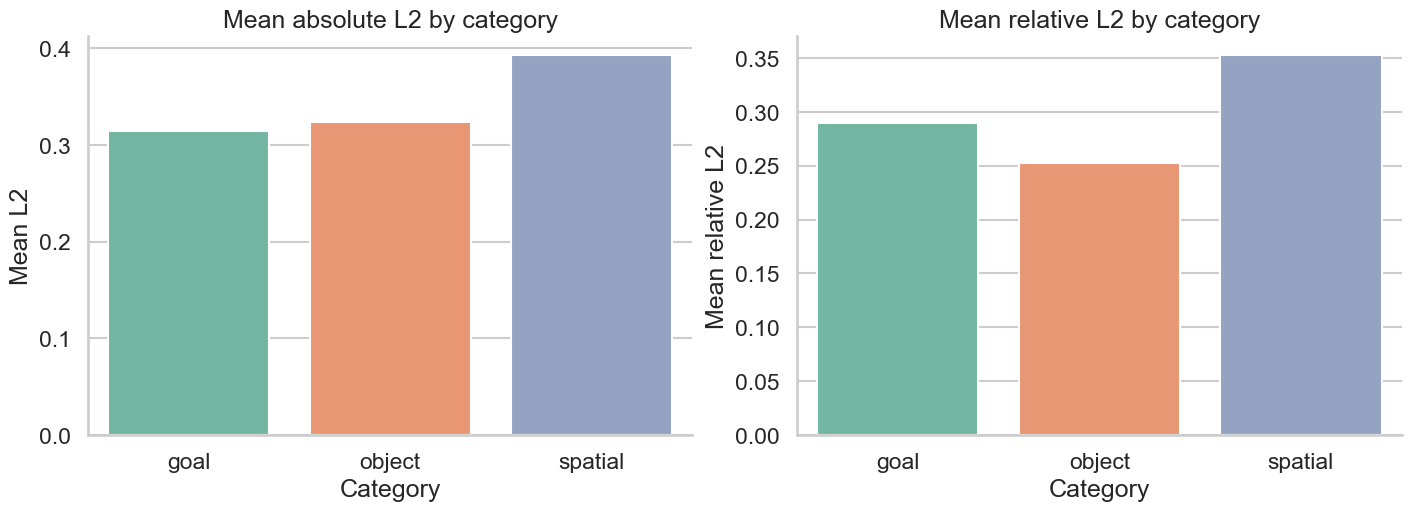

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
plot_df = category_overview.reset_index()

sns.barplot(data=plot_df, x="category", y="mean_l2", ax=axes[0], palette="Set2")
axes[0].set_title("Mean absolute L2 by category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Mean L2")

sns.barplot(data=plot_df, x="category", y="mean_rel_l2", ax=axes[1], palette="Set2")
axes[1].set_title("Mean relative L2 by category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Mean relative L2")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()

## 4. Variant Comparison

These heatmaps compare the average variant sensitivity across categories.

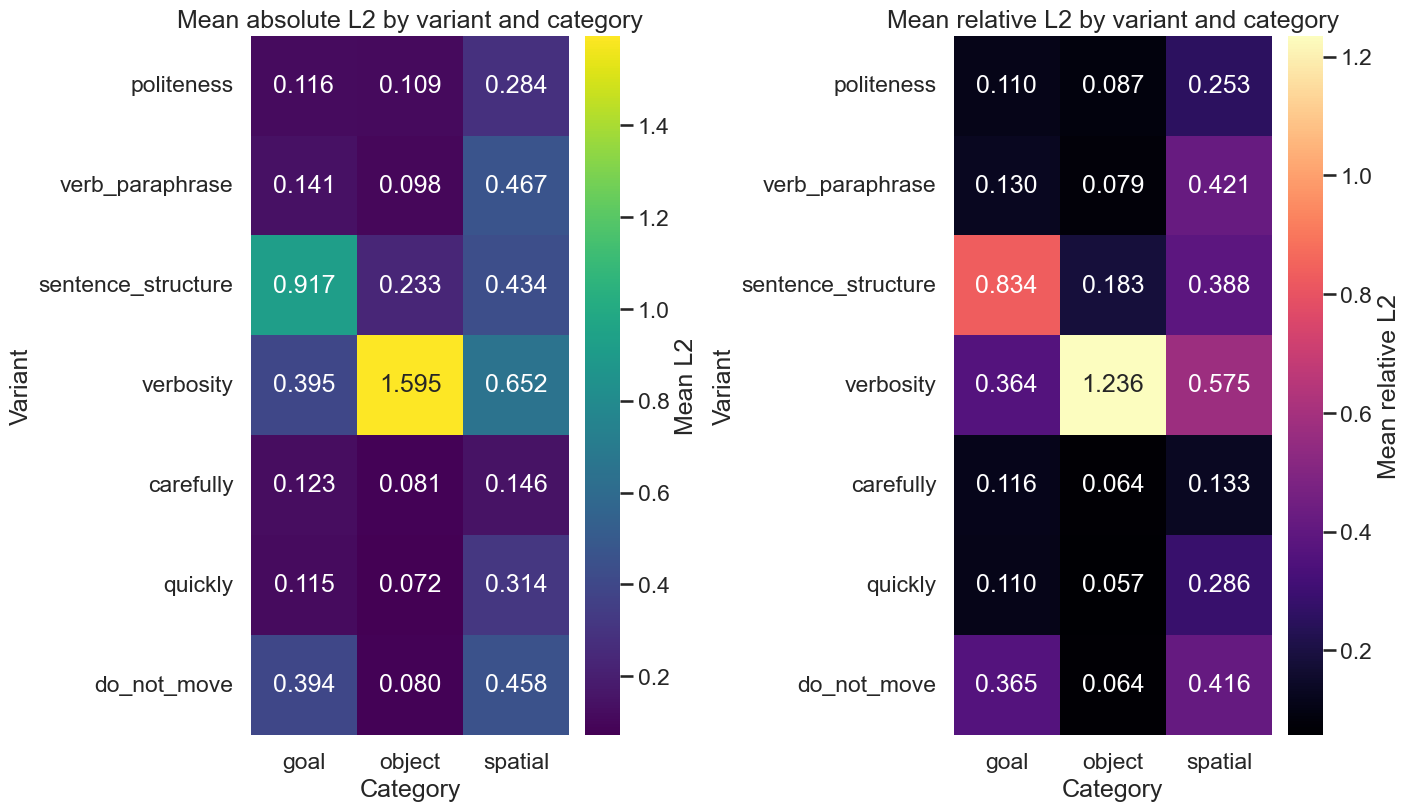

In [ ]:
variant_name_map = {"do_not_move": "negation"}
variant_name_map = {"do_not_move": "negation"}
variant_name_map = {"do_not_move": "negation"}
variant_order = list(next(iter(categories.values()))["variant_types"].keys())
variant_l2_pivot = variant_df.pivot(index="variant", columns="category", values="mean_l2").reindex(variant_order)
variant_rel_pivot = variant_df.pivot(index="variant", columns="category", values="mean_rel_l2").reindex(variant_order)
# Use display names for the pivot indexes
variant_l2_pivot.index = [variant_name_map.get(i, i).replace("_", " .title() for i in variant_l2_pivot.index]
variant_rel_pivot.index = [variant_name_map.get(i, i).replace("_", " .title() for i in variant_rel_pivot.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 8), constrained_layout=True)
sns.heatmap(variant_l2_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[0], cbar_kws={"label": "Mean L2"})
axes[0].set_title("Mean absolute L2 by variant and category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Variant")

sns.heatmap(variant_rel_pivot, annot=True, fmt=".3f", cmap="magma", ax=axes[1], cbar_kws={"label": "Mean relative L2"})
axes[1].set_title("Mean relative L2 by variant and category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Variant")

plt.show()

### Variant ranking

This table ranks variants within each category by mean absolute L2.

In [9]:
ranking = (
    variant_df.sort_values(["category", "mean_l2"], ascending=[True, False])
    .groupby("category")
    .head(8)
)
display(ranking[["category", "variant", "mean_l2", "mean_rel_l2", "n_rollouts"]].style.format({
    "mean_l2": "{:.4f}",
    "mean_rel_l2": "{:.4f}",
}))

,category,variant,mean_l2,mean_rel_l2,n_rollouts
2,goal,sentence_structure,0.9169,0.8345,250
3,goal,verbosity,0.3954,0.3640,250
6,goal,do_not_move,0.3938,0.3648,250
1,goal,verb_paraphrase,0.1410,0.1304,250
4,goal,carefully,0.1228,0.1161,250
0,goal,politeness,0.1158,0.1097,250
5,goal,quickly,0.1155,0.1101,250
10,object,verbosity,1.5949,1.2355,250
9,object,sentence_structure,0.2334,0.1825,250
7,object,politeness,0.1094,0.0869,250


## 5. Timestep Curves - Absolute L2

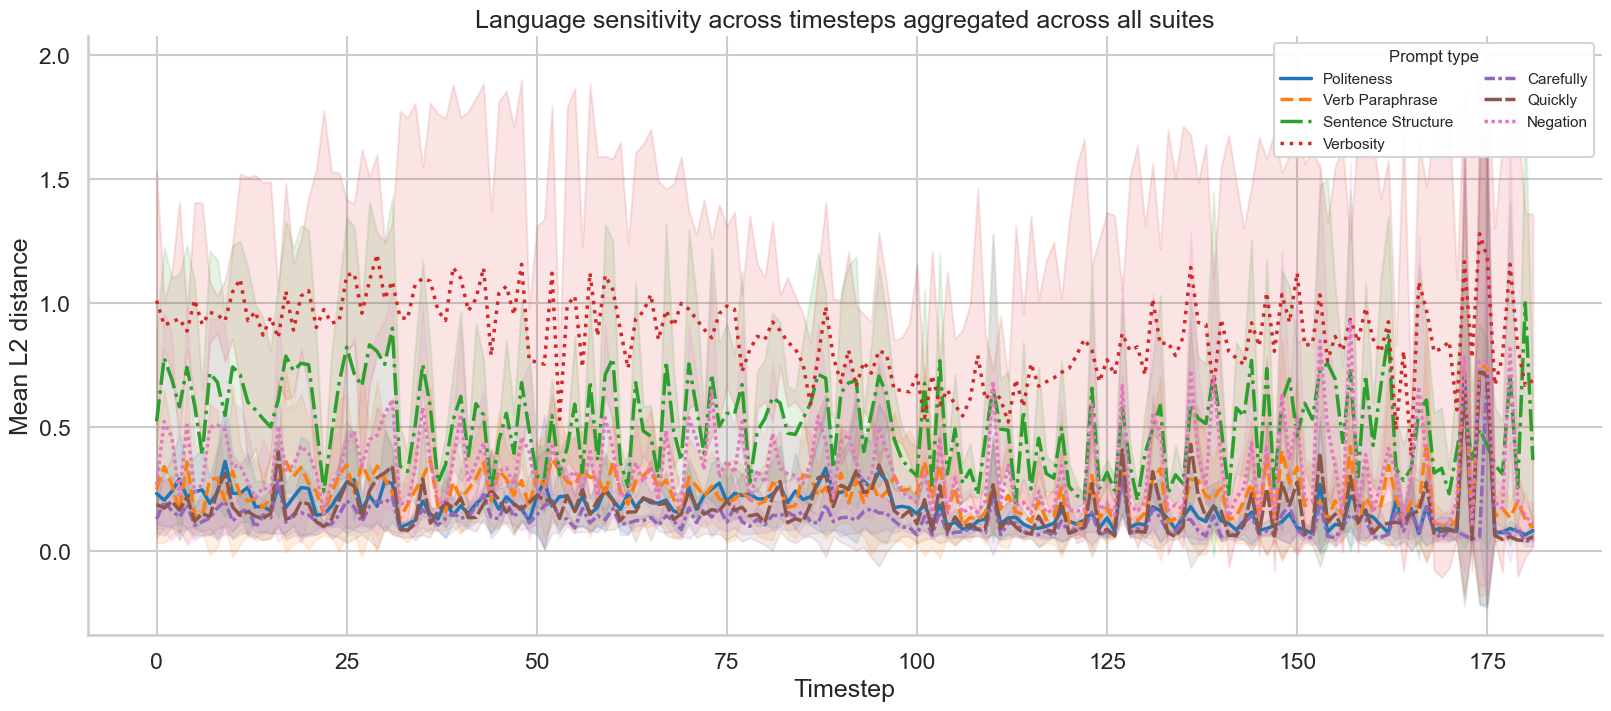

In [16]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

variant_order = list(next(iter(categories.values()))["variant_types"].keys())

variant_palette = dict(zip(
    variant_order,
    sns.color_palette("tab10", n_colors=len(variant_order))
))

variant_styles = dict(zip(
    variant_order,
    ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1)), (0, (5, 2, 1, 2))]
))

combined_figure_data = {}

for variant_name in variant_order:
    curves = []

    for suite_name, suite_summary in categories.items():
        variant_summary = suite_summary["variant_types"][variant_name]
        curve = np.asarray(variant_summary["mean_l2_per_timestep"])
        curves.append(curve)

    min_len = min(len(curve) for curve in curves)
    curves = [curve[:min_len] for curve in curves]

    stacked = np.stack(curves, axis=0)

    combined_figure_data[variant_name] = {
        "mean": stacked.mean(axis=0),
        "std": stacked.std(axis=0),
        "timesteps": np.asarray(timesteps[:min_len]),
    }

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)

for variant_name in variant_order:
    mean_curve = combined_figure_data[variant_name]["mean"]
    std_curve = combined_figure_data[variant_name]["std"]
    x = combined_figure_data[variant_name]["timesteps"]
    display_name = variant_name_map.get(variant_name, variant_name).replace("_", " ").title()

    ax.plot(
        x,
        mean_curve,
        label=display_name,
        color=variant_palette[variant_name],
        linestyle=variant_styles[variant_name],
        linewidth=2.5,
    )

    ax.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        color=variant_palette[variant_name],
        alpha=0.12,
    )

ax.set_title("Language sensitivity across timesteps aggregated across all suites")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean L2 distance")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Prompt type",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="upper right",
    fontsize=11,
    title_fontsize=12,
)

plt.show()

### 5.1 Spatial


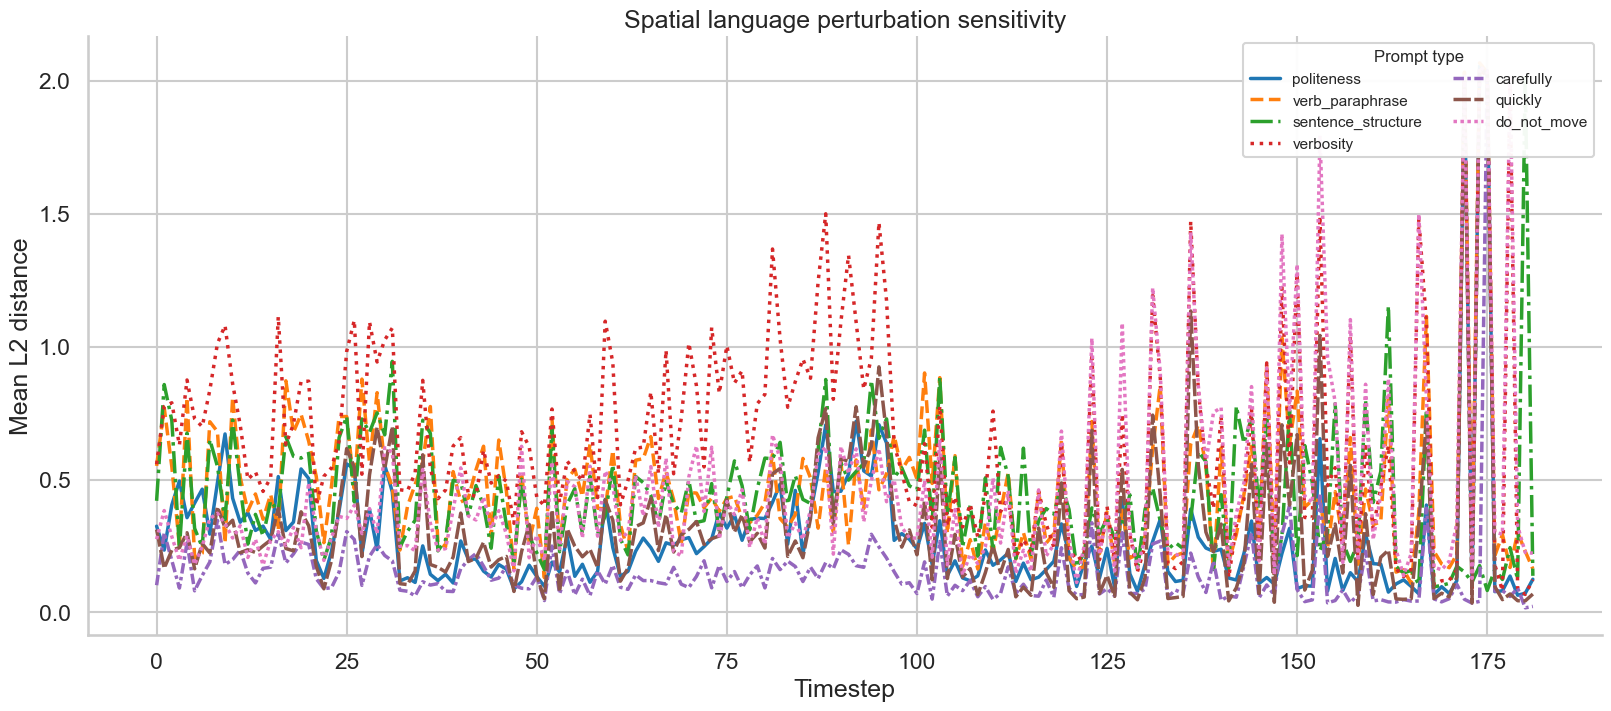

In [ ]:
suite_name = "spatial"
fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
suite_summary = categories[suite_name]
variant_name_map = {"do_not_move": "negation"}
for variant_name in variant_order:
    variant_summary = suite_summary["variant_types"][variant_name]
    curve = np.asarray(variant_summary["mean_l2_per_timestep"])
    x = np.asarray(timesteps[:len(curve)])
    display_name = variant_name_map.get(variant_name, variant_name).replace("_", " .title()
    ax.plot(
        x,
        curve,
        label=display_name,
        color=variant_palette[variant_name],
        linestyle=variant_styles[variant_name],
        linewidth=2.5,
    )

ax.set_title("Spatial language perturbation sensitivity")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean L2 distance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Prompt type",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="upper right",
    fontsize=11,
    title_fontsize=12,
)


plt.show()

### 5.2. Goal

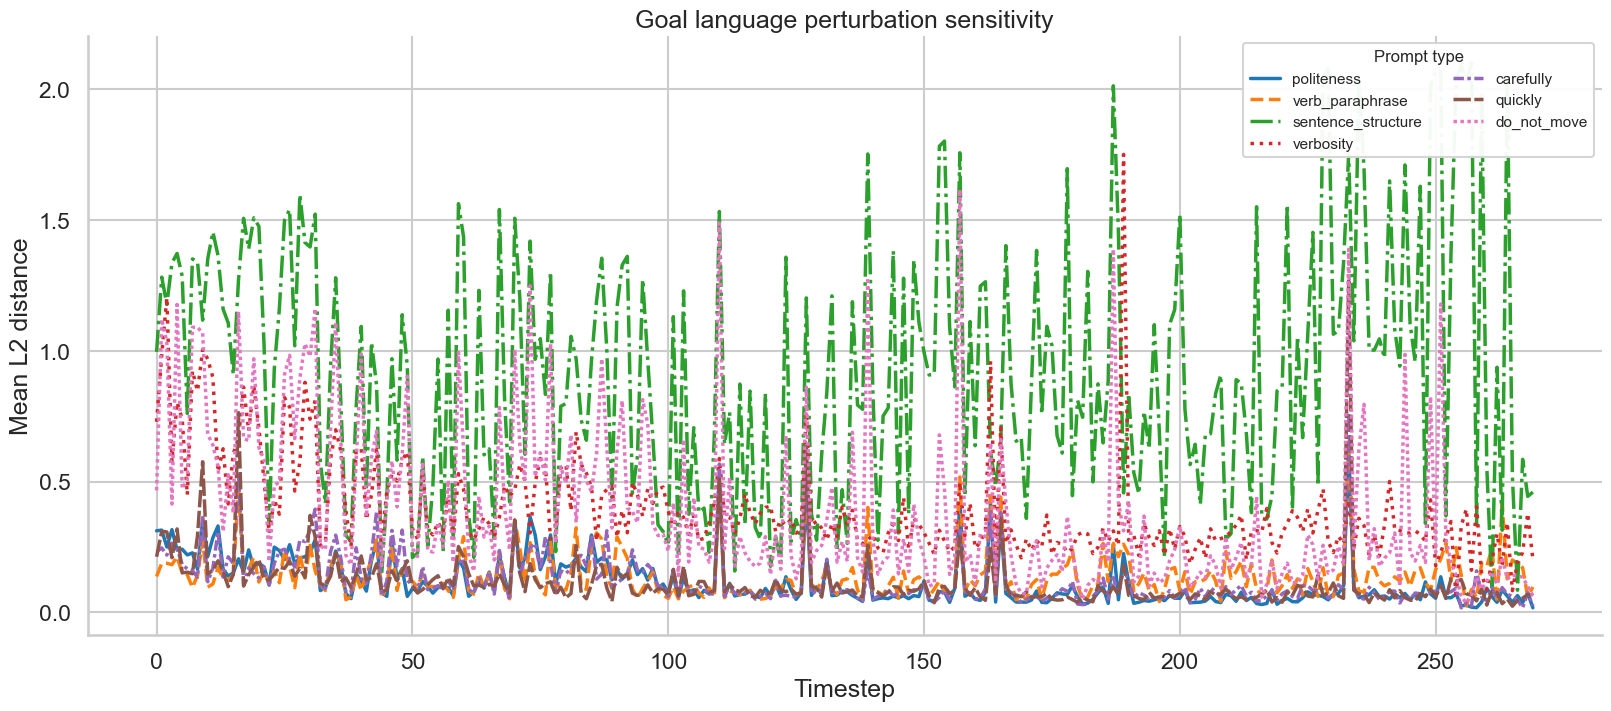

In [ ]:
suite_name = "object"
fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
suite_summary = categories[suite_name]
variant_name_map = {"do_not_move": "negation"}
for variant_name in variant_order:
    variant_summary = suite_summary["variant_types"][variant_name]
    curve = np.asarray(variant_summary["mean_rel_l2_per_timestep"])
    x = np.asarray(timesteps[:len(curve)])
    display_name = variant_name_map.get(variant_name, variant_name).replace("_", " .title()
    ax.plot(
        x,
        curve,
        label=display_name,
        color=variant_palette[variant_name],
        linestyle=variant_styles[variant_name],
        linewidth=2.5,
    )
    title="Prompt type",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="upper right",
    fontsize=11,
    title_fontsize=12,
)


plt.show()

### 5.3. Object

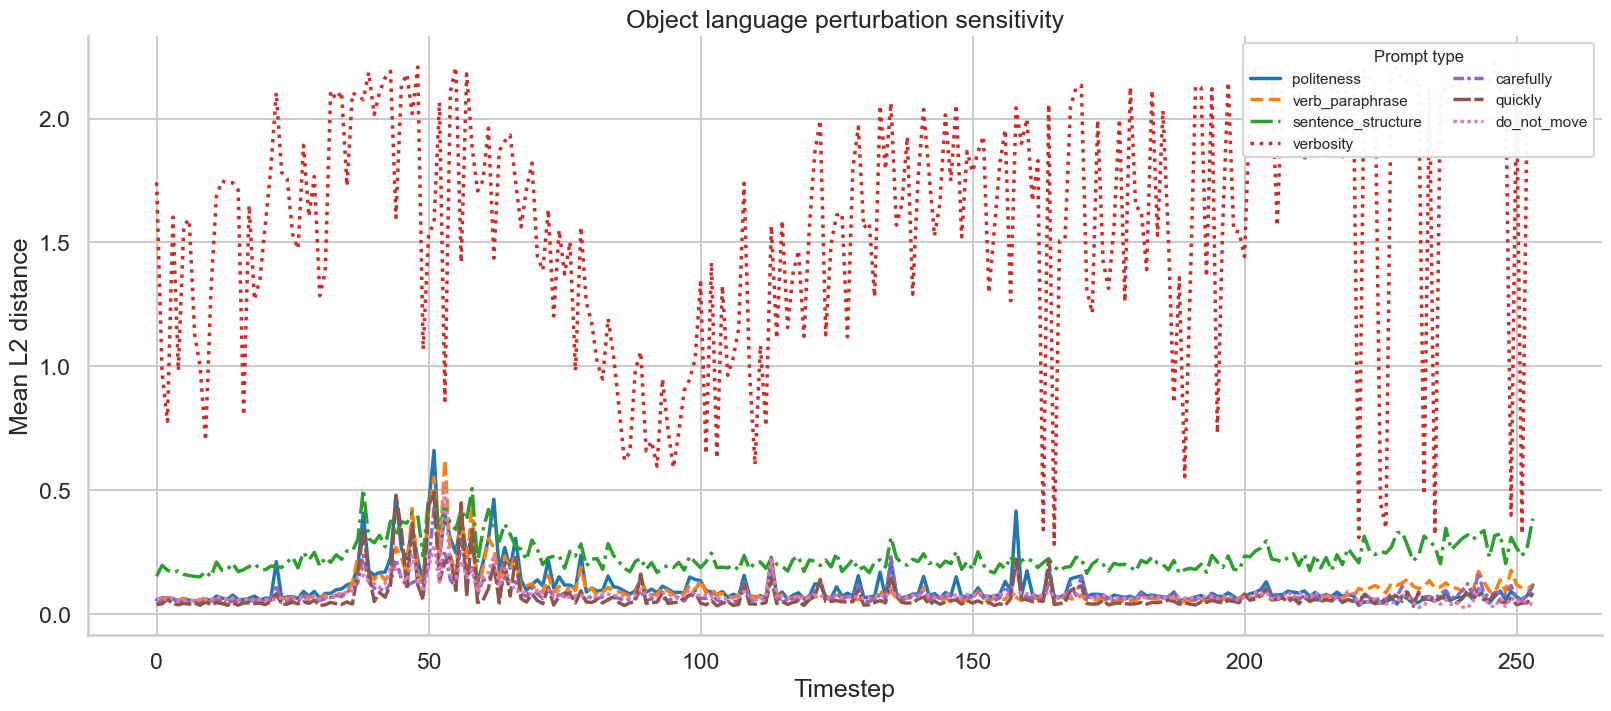

In [36]:
suite_name = "object"

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)

suite_summary = categories[suite_name]

for variant_name in variant_order:
    variant_summary = suite_summary["variant_types"][variant_name]

    curve = np.asarray(variant_summary["mean_l2_per_timestep"])
    x = np.asarray(timesteps[:len(curve)])

    ax.plot(
        x,
        curve,
        label=variant_name,
        color=variant_palette[variant_name],
        linestyle=variant_styles[variant_name],
        linewidth=2.5,
    )

ax.set_title("Object language perturbation sensitivity")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean L2 distance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Prompt type",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="upper right",
    fontsize=11,
    title_fontsize=12,
)


plt.show()

# 6. Timestep curve - Relative L2

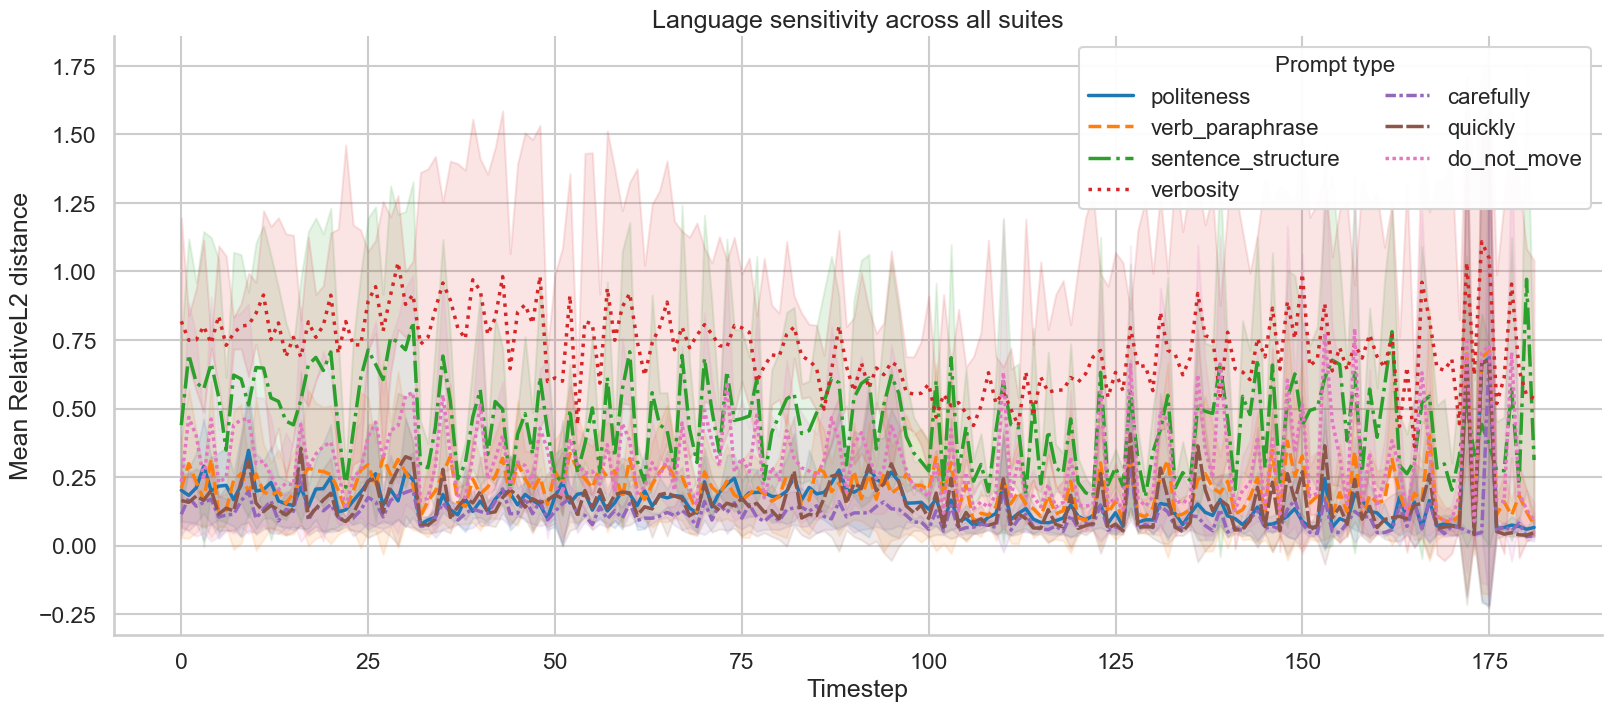

In [ ]:
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

variant_order = list(next(iter(categories.values()))["variant_types"].keys())

variant_palette = dict(zip(
    variant_order,
    sns.color_palette("tab10", n_colors=len(variant_order))
))

variant_styles = dict(zip(
    variant_order,
    ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1)), (0, (5, 2, 1, 2))]
))

combined_figure_data = {}

for variant_name in variant_order:
    curves = []

    for suite_name, suite_summary in categories.items():
        variant_summary = suite_summary["variant_types"][variant_name]
        curve = np.asarray(variant_summary["mean_rel_l2_per_timestep"])
        curves.append(curve)

    min_len = min(len(curve) for curve in curves)
    curves = [curve[:min_len] for curve in curves]

    stacked = np.stack(curves, axis=0)

    combined_figure_data[variant_name] = {
        "mean": stacked.mean(axis=0),
        "std": stacked.std(axis=0),
        "timesteps": np.asarray(timesteps[:min_len]),
    }

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)

for variant_name in variant_order:
    mean_curve = combined_figure_data[variant_name]["mean"]
    std_curve = combined_figure_data[variant_name]["std"]
    x = combined_figure_data[variant_name]["timesteps"]
    display_name = variant_name_map.get(variant_name, variant_name).replace("_", " .title()

    ax.plot(
        x,
        mean_curve,
        label=display_name,
        color=variant_palette[variant_name],
        linestyle=variant_styles[variant_name],
        linewidth=2.5,
    )

    ax.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        color=variant_palette[variant_name],
        alpha=0.12,
    )

ax.set_title("Language sensitivity across all suites")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean RelativeL2 distance")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Prompt type",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="upper right",
    fontsize=16,
    title_fontsize=16,
)

plt.show()

### 6.1 - Spatial

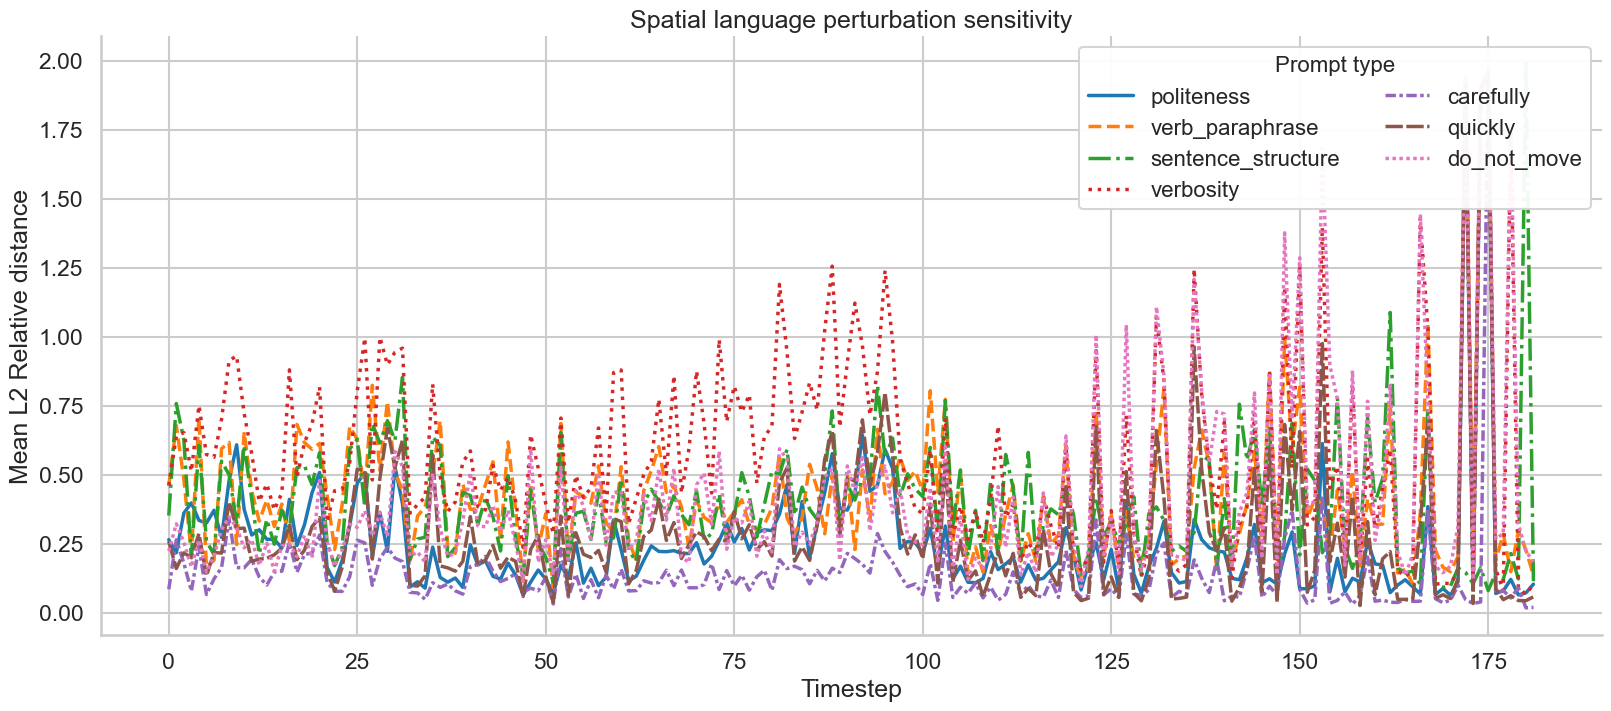

In [ ]:
suite_name = "spatial"
fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
suite_summary = categories[suite_name]
variant_name_map = {"do_not_move": "negation"}
for variant_name in variant_order:
    variant_summary = suite_summary["variant_types"][variant_name]
    curve = np.asarray(variant_summary["mean_rel_l2_per_timestep"])
    x = np.asarray(timesteps[:len(curve)])
    display_name = variant_name_map.get(variant_name, variant_name).replace("_", " .title()
    ax.plot(
        x,
        curve,
        label=display_name,
        color=variant_palette[variant_name],
        linestyle=variant_styles[variant_name],
        linewidth=2.5,
    )

ax.set_title("Spatial language perturbation sensitivity")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean L2 Relative distance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Prompt type",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="upper right",
    fontsize=16,
    title_fontsize=16,
)


plt.show()

### 6.2 - Goal

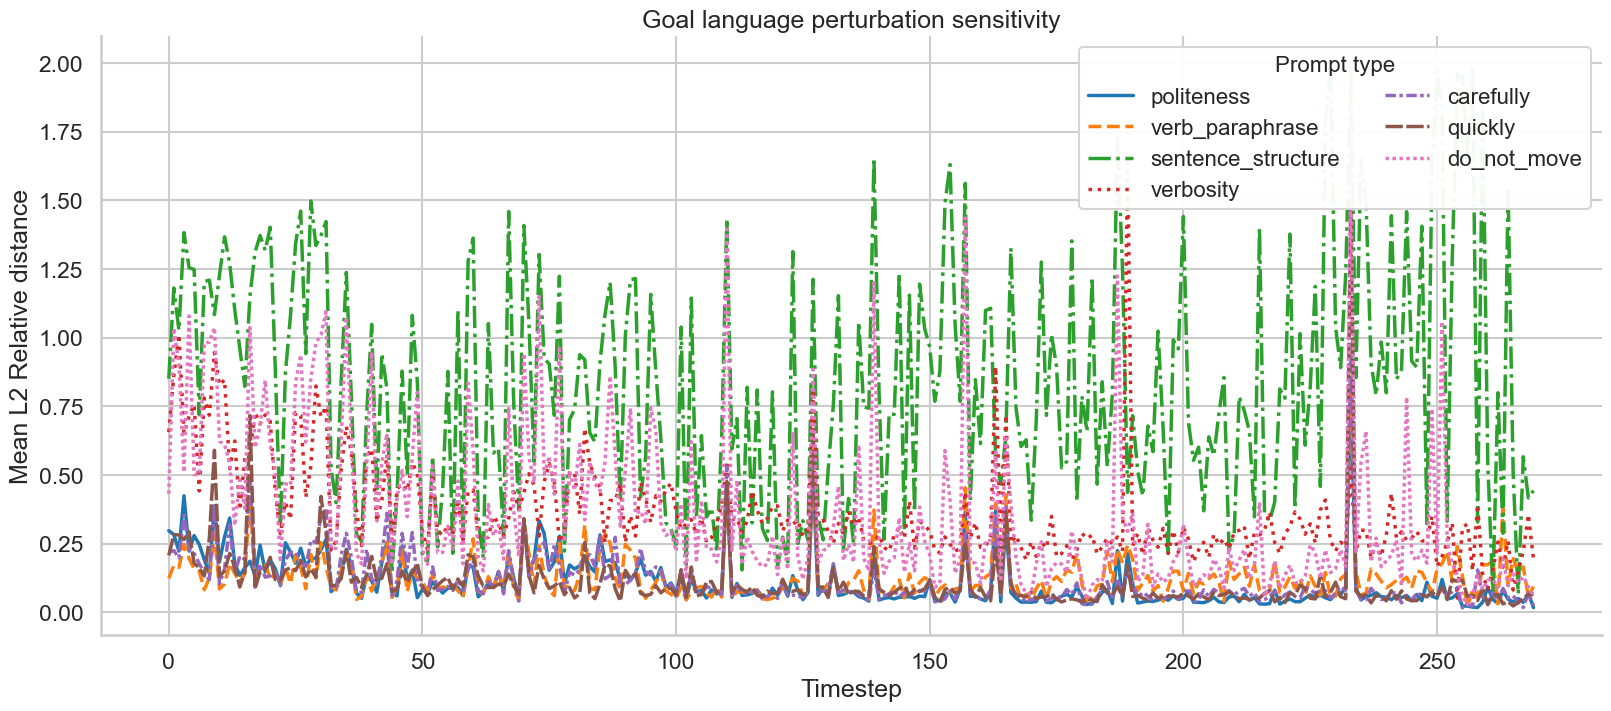

In [43]:
suite_name = "goal"

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)

suite_summary = categories[suite_name]

for variant_name in variant_order:
    variant_summary = suite_summary["variant_types"][variant_name]

    curve = np.asarray(variant_summary["mean_rel_l2_per_timestep"])
    x = np.asarray(timesteps[:len(curve)])

    ax.plot(
        x,
        curve,
        label=variant_name,
        color=variant_palette[variant_name],
        linestyle=variant_styles[variant_name],
        linewidth=2.5,
    )

ax.set_title("Goal language perturbation sensitivity")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean L2 Relative distance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Prompt type",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="upper right",
    fontsize=16,
    title_fontsize=16,
)


plt.show()

### 6.3 - Object

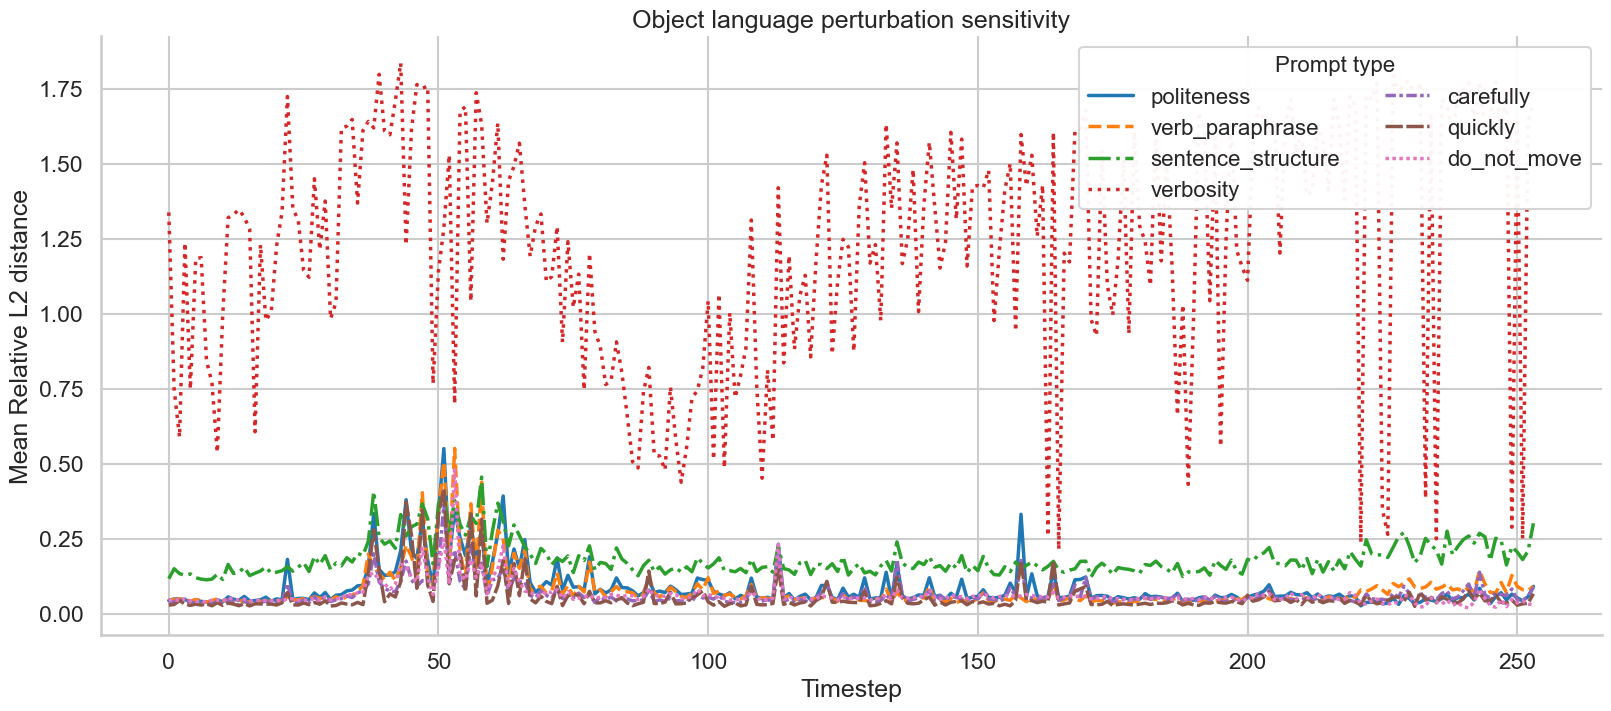

In [ ]:
suite_name = "object"

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)

suite_summary = categories[suite_name]

for variant_name in variant_order:
    variant_summary = suite_summary["variant_types"][variant_name]

    curve = np.asarray(variant_summary["mean_rel_l2_per_timestep"])
    x = np.asarray(timesteps[:len(curve)])

    ax.plot(
        x,
        curve,
        label=variant_name,
        color=variant_palette[variant_name],
        linestyle=variant_styles[variant_name],
        linewidth=2.5,
    )

ax.set_title("Object language perturbation sensitivity")
ax.set_xlabel("Timestep")
ax.set_ylabel("Mean Relative L2 distance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Prompt type",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="upper right",
    fontsize=16,
    title_fontsize=16,
)


plt.show()

## 7. Per-Task Summary

For each category, we can also identify the most and least sensitive tasks.

In [9]:
for category_name in task_df['category'].unique():
    print(f"\n=== {category_name.upper()} ===")
    subset = task_df[task_df['category'] == category_name].sort_values("mean_l2", ascending=False)
    display(subset.head(5).reset_index(drop=True).style.format({
        "mean_l2": "{:.4f}",
        "mean_rel_l2": "{:.4f}",
    }))
    print("Lowest 5 tasks:")
    display(subset.tail(5).sort_values("mean_l2").reset_index(drop=True).style.format({
        "mean_l2": "{:.4f}",
        "mean_rel_l2": "{:.4f}",
    }))


=== GOAL ===


,category,task,mean_l2,mean_rel_l2,variant_count
0,goal,put the bowl on the plate,0.5108,0.4665,7
1,goal,open the top drawer and put the bowl inside,0.3181,0.2828,7
2,goal,put the wine bottle on the rack,0.3059,0.2931,7
3,goal,put the cream cheese in the bowl,0.3011,0.2913,7
4,goal,put the wine bottle on top of the cabinet,0.2741,0.2569,7


Lowest 5 tasks:


,category,task,mean_l2,mean_rel_l2,variant_count
0,goal,put the wine bottle on top of the cabinet,0.2741,0.2569,7
1,goal,put the cream cheese in the bowl,0.3011,0.2913,7
2,goal,put the wine bottle on the rack,0.3059,0.2931,7
3,goal,open the top drawer and put the bowl inside,0.3181,0.2828,7
4,goal,put the bowl on the plate,0.5108,0.4665,7



=== OBJECT ===


...

,category,task,mean_l2,mean_rel_l2,variant_count
0,object,pick up the orange juice and place it in the basket,0.2536,0.1995,7
1,object,pick up the alphabet soup and place it in the basket,0.2627,0.2015,7
2,object,pick up the cream cheese and place it in the basket,0.3454,0.2735,7
3,object,pick up the ketchup and place it in the basket,0.3527,0.2711,7
4,object,pick up the bbq sauce and place it in the basket,0.3842,0.3013,7



=== SPATIAL ===


,category,task,mean_l2,mean_rel_l2,variant_count
0,spatial,pick up the black bowl on the stove and place it on the plate,0.4879,0.4229,7
1,spatial,pick up the black bowl in the top drawer of the wooden cabinet and place it on the plate,0.4137,0.3746,7
2,spatial,pick up the black bowl on the ramekin and place it on the plate,0.3603,0.3058,7
3,spatial,pick up the black bowl between the plate and the ramekin and place it on the plate,0.3300,0.2948,7
4,spatial,pick up the black bowl next to the cookie box and place it on the plate,0.2944,0.2808,7


Lowest 5 tasks:


,category,task,mean_l2,mean_rel_l2,variant_count
0,spatial,pick up the black bowl next to the cookie box and place it on the plate,0.2944,0.2808,7
1,spatial,pick up the black bowl between the plate and the ramekin and place it on the plate,0.3300,0.2948,7
2,spatial,pick up the black bowl on the ramekin and place it on the plate,0.3603,0.3058,7
3,spatial,pick up the black bowl in the top drawer of the wooden cabinet and place it on the plate,0.4137,0.3746,7
4,spatial,pick up the black bowl on the stove and place it on the plate,0.4879,0.4229,7


/tmp/pbs.666845.hnode41/ipykernel_1487300/2543655356.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


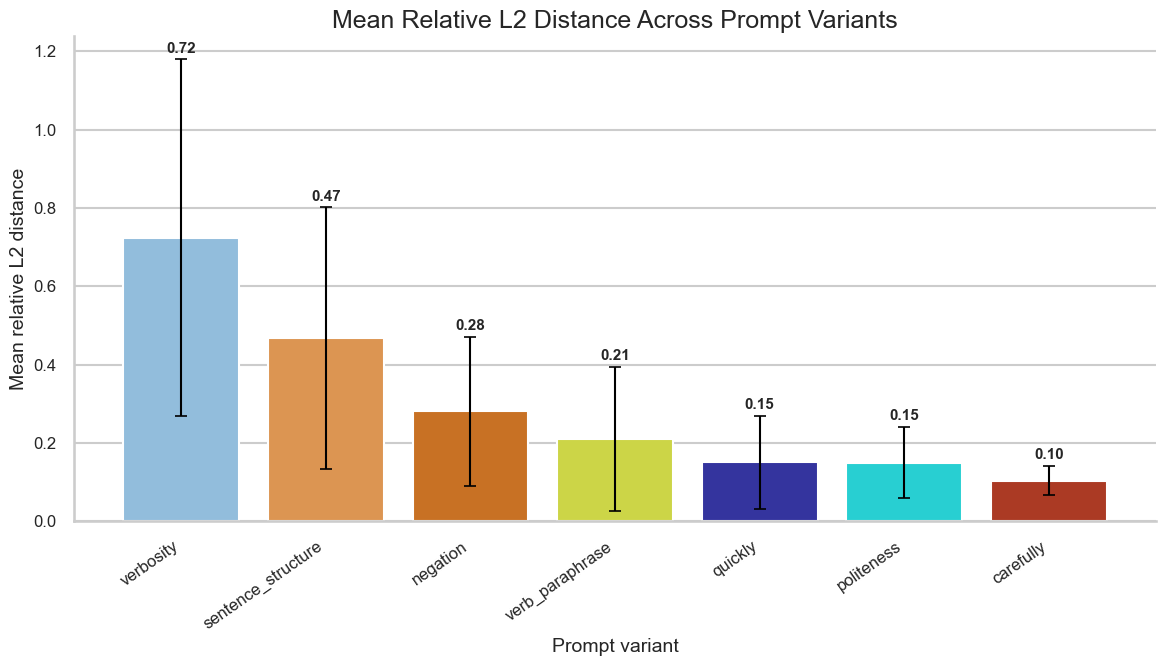

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Optional cleaner display names
variant_name_map = {
    "do_not_move": "negation",
}

# Apply display names
overall_summary["display_name"] = (
    overall_summary["variant_type"]
    .map(variant_name_map)
    .fillna(overall_summary["variant_type"])
)

# Sort by mean relative L2
overall_summary = overall_summary.sort_values(
    "mean_rel_l2",
    ascending=False
)

custom_colors = [
    "#86BFE8",
    "#F3943B",
    "#E36F09",
    "#E0ED2F",
    "#2222B0",
    "#0CEAEE",
    "#C12B0D",
]

# Create figure
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=overall_summary,
    x="display_name",
    y="mean_rel_l2",
    palette=custom_colors,
)

# Error bars (std across suites)
x_positions = np.arange(len(overall_summary))

ax.errorbar(
    x=x_positions,
    y=overall_summary["mean_rel_l2"],
    yerr=overall_summary["std_across_suites"],
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=4,
    capthick=1.2,
)

# Labels above bars
for i, row in overall_summary.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["mean_rel_l2"] + row["std_across_suites"] + 0.01,
        f'{row["mean_rel_l2"]:.2f}',
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

ax.set_title(
    "Mean Relative L2 Distance Across Prompt Variants",
    fontsize=18,
)

ax.set_xlabel(
    "Prompt variant",
    fontsize=14,
)

ax.set_ylabel(
    "Mean relative L2 distance",
    fontsize=14,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=35, ha="right", fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## Mean Relative L2 Across Prompt Variants and Suites

The next cell plots the mean relative L2 distance for each prompt variant, with the three suites shown side by side within each variant.

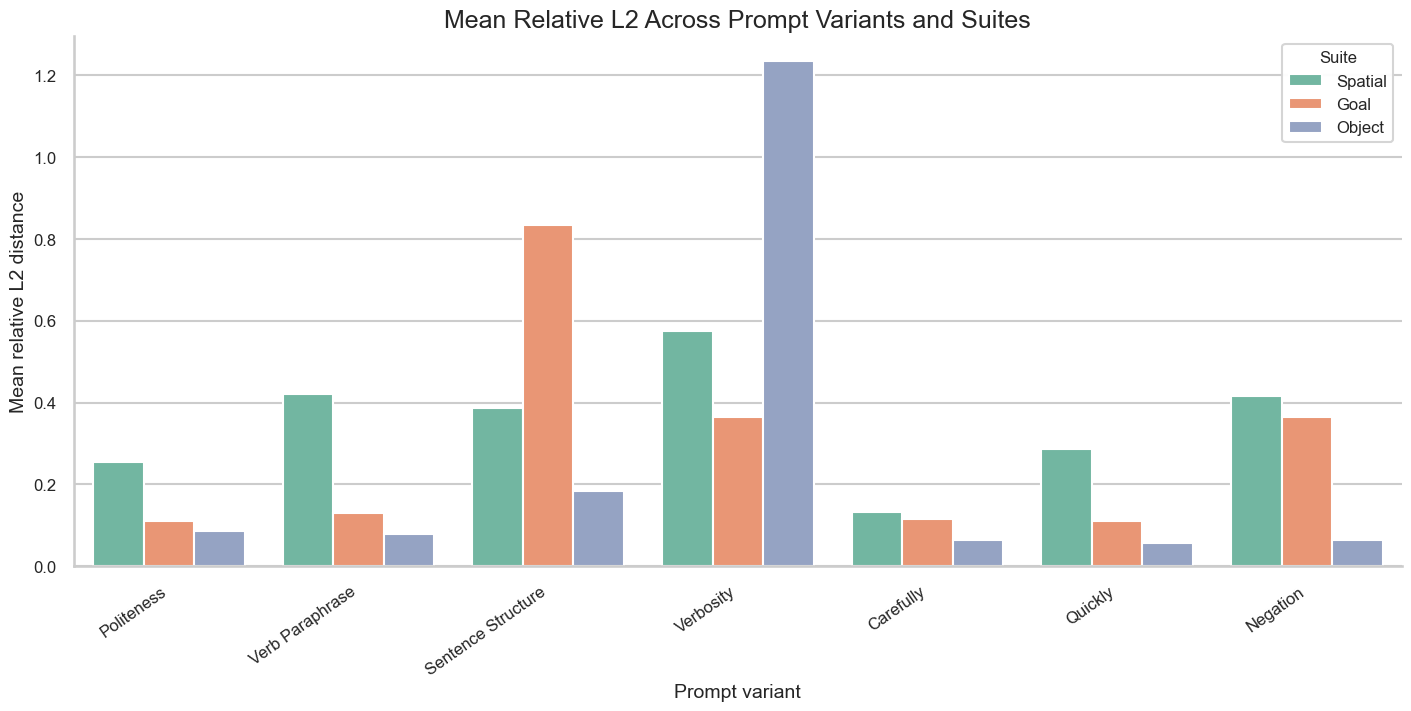

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

variant_name_map = {
    "do_not_move": "negation",
}

suite_order = ["spatial", "goal", "object"]
variant_order = list(next(iter(categories.values()))["variant_types"].keys())
variant_display_order = [
    variant_name_map.get(variant_name, variant_name).replace("_", " ").title()
    for variant_name in variant_order
]

plot_rows = []
for suite_name in suite_order:
    suite_summary = categories[suite_name]
    for variant_name in variant_order:
        variant_summary = suite_summary["variant_types"][variant_name]
        plot_rows.append(
            {
                "suite": suite_name.title(),
                "prompt_variant": variant_name_map.get(variant_name, variant_name).replace("_", " ").title(),
                "mean_rel_l2": float(np.mean(variant_summary["mean_rel_l2_per_timestep"])),
            }
        )

plot_df = pd.DataFrame(plot_rows)
plot_df["prompt_variant"] = pd.Categorical(
    plot_df["prompt_variant"],
    categories=variant_display_order,
    ordered=True,
)
plot_df["suite"] = pd.Categorical(
    plot_df["suite"],
    categories=[suite_name.title() for suite_name in suite_order],
    ordered=True,
)

fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)

sns.barplot(
    data=plot_df,
    x="prompt_variant",
    y="mean_rel_l2",
    hue="suite",
    order=variant_display_order,
    hue_order=[suite_name.title() for suite_name in suite_order],
    palette="Set2",
    ax=ax,
)

ax.set_title("Mean Relative L2 Across Prompt Variants and Suites", fontsize=18)
ax.set_xlabel("Prompt variant", fontsize=14)
ax.set_ylabel("Mean relative L2 distance", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    title="Suite",
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    framealpha=0.95,
    loc="best",
    fontsize=12,
    title_fontsize=12,
)

plt.xticks(rotation=35, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.show()